# SPEC 06 — LIN28A BAM-level Candidate Validation

**Objective**: Validate selected high-confidence LIN28A direct translational repression targets at the locus level using CLIP-seq, RPF, and RNA-seq BAM files.

| Candidate | Type | Table S5 CLIP enrich | Ribo Δ (log2) | mRNA Δ (log2) | Binding sites |
|---|---|---|---|---|---|
| Pgrmc1 | A∩B positive | 4.031 | +0.315 | −0.220 | 21 |
| Ktn1   | A∩B positive | 2.913 | +0.605 | −0.399 | 62 |
| Pvrl3  | A∩B positive | 2.882 | +0.867 | −0.324 | 17 |
| Unc45a | Not_candidate (negative control) | −1.861 | −1.965 | +0.016 | 0 |

> **Note**: `samtools` was run via `conda run -n samtools samtools`.
> `Pvrl3` was looked up in GENCODE vM27 as `Nectin3` (alias).
> Coverage: `samtools depth -aa` + Python 0-fill. RPM normalization by mapped reads.

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import sys, os

BASE  = '/home/sezero/data/BI_2026-1/Guided_Mission_1/colab-biolab/lin28a_project'
OUT_T = f'{BASE}/results/tables'
OUT_F = f'{BASE}/results/figures'
OUT_C = f'{BASE}/results/coverage'

DATADIR = '/home/sezero/data/BI_2026-1/Guided_Mission_1/colab-biolab/tools/binfo1-datapack1'
BAMS = {
    'CLIP_35L33G':  f'{DATADIR}/CLIP-35L33G.bam',
    'RPF_siLuc':    f'{DATADIR}/RPF-siLuc.bam',
    'RPF_siLin28a': f'{DATADIR}/RPF-siLin28a.bam',
    'RNA_siLuc':    f'{DATADIR}/RNA-siLuc.bam',
    'RNA_siLin28a': f'{DATADIR}/RNA-siLin28a.bam',
}

ribo_col = 'Ribosome density change (log2)'
rna_col  = 'RNA-seq mRNA change upon Lin28a KD (log2)'
clip_col = 'mean_CLIP_enrichment'

print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}  numpy: {np.__version__}  matplotlib: {matplotlib.__version__}')

Python: 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
pandas: 2.3.3  numpy: 2.2.6  matplotlib: 3.10.8


## 1. Gene coordinates (GENCODE vM27, ±1,000 bp flank)

In [2]:
df_coords = pd.read_csv(f'{OUT_T}/06_selected_gene_coordinates.csv')
df_coords[['candidate_gene_symbol','gtf_gene_name','alias_mapping_used',
           'chrom','start_1b','end_1b','strand','gene_length_bp','region_str']]

,candidate_gene_symbol,gtf_gene_name,alias_mapping_used,chrom,start_1b,end_1b,strand,gene_length_bp,region_str
0,Pgrmc1,Pgrmc1,False,chrX,35861859,35869732,+,7874,chrX:35860859-35870732
1,Ktn1,Ktn1,False,chr14,47885905,47977351,+,91447,chr14:47884905-47978351
2,Pvrl3,Nectin3,True,chr16,46208069,46318888,-,110820,chr16:46207069-46319888
3,Unc45a,Unc45a,False,chr7,79975040,79997741,-,22702,chr7:79974040-79998741


## 2. Library sizes (samtools idxstats)

RPM factor used for coverage normalization: `raw_depth / (mapped_reads / 1e6)`

In [3]:
df_lib = pd.read_csv(f'{OUT_T}/06_bam_library_size_summary.csv')
df_lib

,sample,label,bam_file,mapped_reads,rpm_factor
0,CLIP_35L33G,CLIP (35L33G),CLIP-35L33G.bam,36589778,36.589778
1,RPF_siLuc,RPF siLuc,RPF-siLuc.bam,41007348,41.007348
2,RPF_siLin28a,RPF siLin28a,RPF-siLin28a.bam,29178323,29.178323
3,RNA_siLuc,RNA-seq siLuc,RNA-siLuc.bam,25785774,25.785774
4,RNA_siLin28a,RNA-seq siLin28a,RNA-siLin28a.bam,32938700,32.938700


## 3. Locus-level coverage figures

Each figure has 3 tracks:
1. **CLIP (35L33G)** — orange fill: LIN28A binding
2. **RPF** — blue (siLuc) vs red (siLin28a): ribosome footprinting
3. **RNA-seq** — blue (siLuc) vs red (siLin28a): mRNA abundance

Gray shading = gene body region. y-axis = RPM-normalized depth. x-axis = genomic coordinate.

> **Caveat**: gene-body region spans introns. RPM normalization is approximate. No biological replicates.

In [4]:
def load_cov(gene_sym, sample):
    sk = sample.replace('_', '-').replace('-', '_')
    p  = f'{OUT_C}/06_{gene_sym}_{sk}_depth.tsv'
    if not os.path.exists(p): return None, None
    df = pd.read_csv(p, sep='\t')
    return df['position'].values, df['rpm_depth'].values

COLORS = {
    'CLIP_35L33G': '#F4A261', 'RPF_siLuc': '#4393C3', 'RPF_siLin28a': '#E63946',
    'RNA_siLuc': '#4393C3',   'RNA_siLin28a': '#E63946',
}
BAM_LABELS = {
    'CLIP_35L33G': 'CLIP (35L33G)', 'RPF_siLuc': 'RPF siLuc',
    'RPF_siLin28a': 'RPF siLin28a', 'RNA_siLuc': 'RNA-seq siLuc',
    'RNA_siLin28a': 'RNA-seq siLin28a',
}


### Pgrmc1

/tmp/claude-1002/ipykernel_341107/1219606484.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


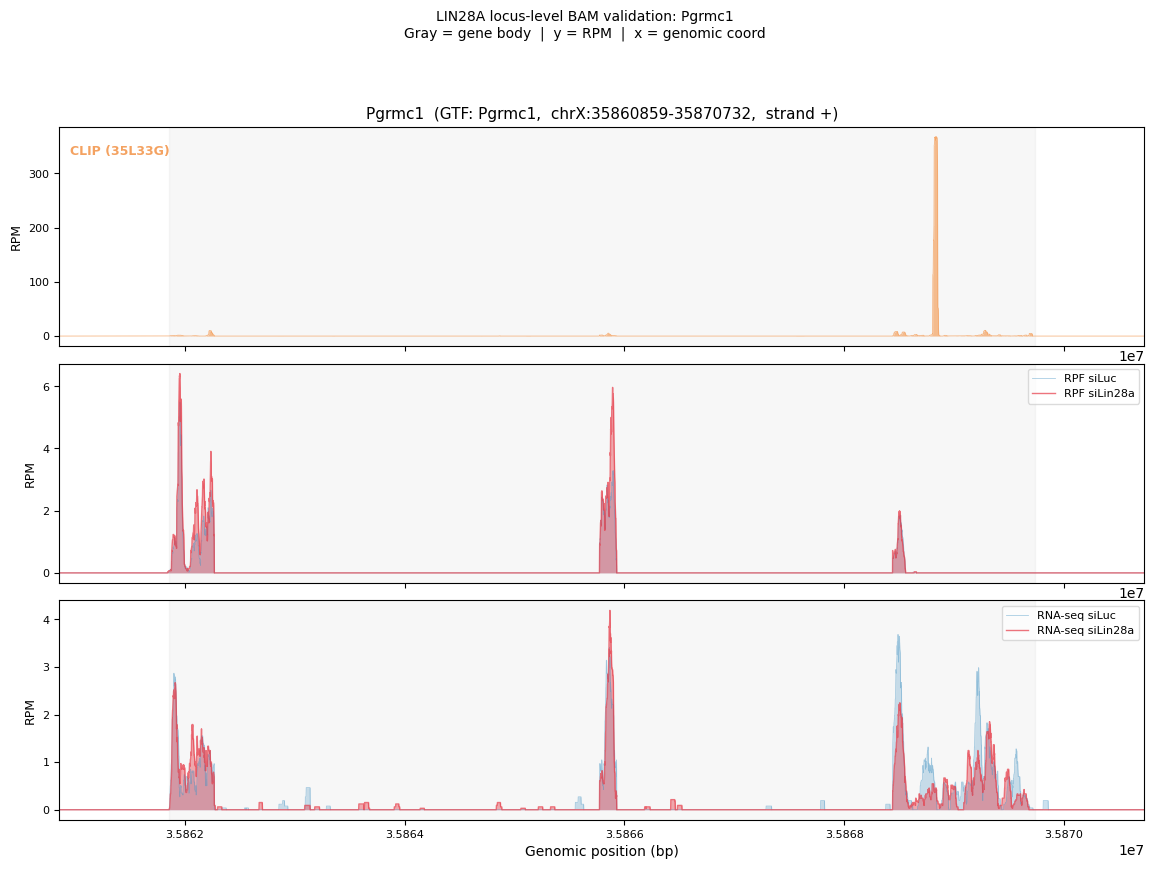

In [5]:
crow = df_coords[df_coords['candidate_gene_symbol'] == 'Pgrmc1'].iloc[0]
gene_sym   = 'Pgrmc1'
region_str = crow['region_str']
gene_s  = int(crow['start_1b'])
gene_e  = int(crow['end_1b'])
region_s = int(crow['region_start_1b'])
region_e = int(crow['region_end_1b'])
strand   = crow['strand']
gtf_name = crow['gtf_gene_name']

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.08, height_ratios=[1,1,1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Track 1: CLIP
pos, rpm = load_cov(gene_sym, 'CLIP_35L33G')
if pos is not None:
    ax1.fill_between(pos, rpm, alpha=0.7, color=COLORS['CLIP_35L33G'], linewidth=0)
    ax1.plot(pos, rpm, color=COLORS['CLIP_35L33G'], linewidth=0.5, alpha=0.9)
ax1.set_ylabel('RPM', fontsize=9)
ax1.set_title(f"Pgrmc1  (GTF: {gtf_name},  {region_str},  strand {strand})", fontsize=11)
ax1.text(0.01, 0.92, 'CLIP (35L33G)', transform=ax1.transAxes,
         fontsize=9, va='top', color=COLORS['CLIP_35L33G'], fontweight='bold')

# Track 2: RPF
for samp, alpha, lw in [('RPF_siLuc',0.45,0.6),('RPF_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax2.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax2.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax2.set_ylabel('RPM', fontsize=9)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.7)

# Track 3: RNA
for samp, alpha, lw in [('RNA_siLuc',0.45,0.6),('RNA_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax3.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax3.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax3.set_ylabel('RPM', fontsize=9)
ax3.set_xlabel('Genomic position (bp)', fontsize=10)
ax3.legend(loc='upper right', fontsize=8, framealpha=0.7)

for ax in [ax1, ax2, ax3]:
    ax.axvspan(gene_s, gene_e, alpha=0.06, color='gray', zorder=0)
    ax.set_xlim(region_s, region_e)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.setp(ax.get_xticklabels(), fontsize=8)
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
fig.suptitle('LIN28A locus-level BAM validation: Pgrmc1\n'
             'Gray = gene body  |  y = RPM  |  x = genomic coord',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

### Ktn1

/tmp/claude-1002/ipykernel_341107/3204722189.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


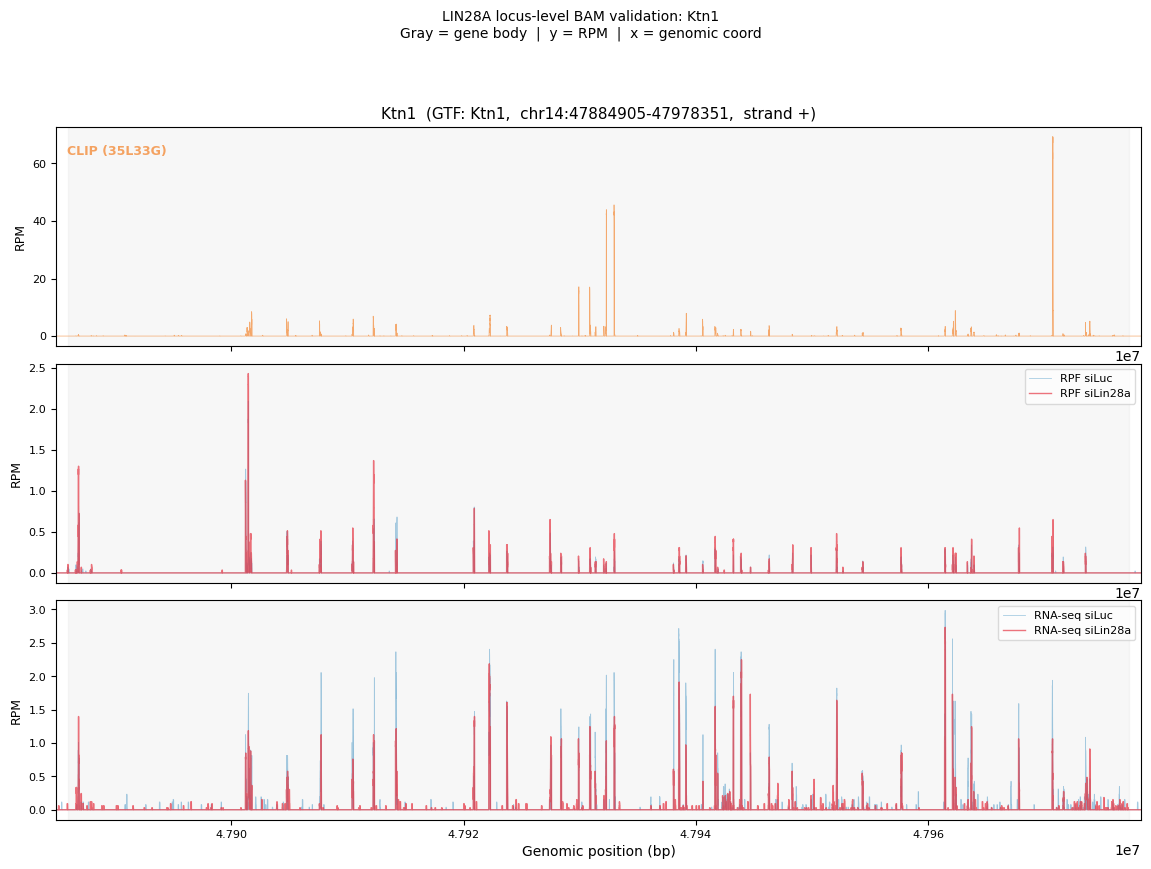

In [6]:
crow = df_coords[df_coords['candidate_gene_symbol'] == 'Ktn1'].iloc[0]
gene_sym   = 'Ktn1'
region_str = crow['region_str']
gene_s  = int(crow['start_1b'])
gene_e  = int(crow['end_1b'])
region_s = int(crow['region_start_1b'])
region_e = int(crow['region_end_1b'])
strand   = crow['strand']
gtf_name = crow['gtf_gene_name']

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.08, height_ratios=[1,1,1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Track 1: CLIP
pos, rpm = load_cov(gene_sym, 'CLIP_35L33G')
if pos is not None:
    ax1.fill_between(pos, rpm, alpha=0.7, color=COLORS['CLIP_35L33G'], linewidth=0)
    ax1.plot(pos, rpm, color=COLORS['CLIP_35L33G'], linewidth=0.5, alpha=0.9)
ax1.set_ylabel('RPM', fontsize=9)
ax1.set_title(f"Ktn1  (GTF: {gtf_name},  {region_str},  strand {strand})", fontsize=11)
ax1.text(0.01, 0.92, 'CLIP (35L33G)', transform=ax1.transAxes,
         fontsize=9, va='top', color=COLORS['CLIP_35L33G'], fontweight='bold')

# Track 2: RPF
for samp, alpha, lw in [('RPF_siLuc',0.45,0.6),('RPF_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax2.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax2.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax2.set_ylabel('RPM', fontsize=9)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.7)

# Track 3: RNA
for samp, alpha, lw in [('RNA_siLuc',0.45,0.6),('RNA_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax3.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax3.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax3.set_ylabel('RPM', fontsize=9)
ax3.set_xlabel('Genomic position (bp)', fontsize=10)
ax3.legend(loc='upper right', fontsize=8, framealpha=0.7)

for ax in [ax1, ax2, ax3]:
    ax.axvspan(gene_s, gene_e, alpha=0.06, color='gray', zorder=0)
    ax.set_xlim(region_s, region_e)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.setp(ax.get_xticklabels(), fontsize=8)
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
fig.suptitle('LIN28A locus-level BAM validation: Ktn1\n'
             'Gray = gene body  |  y = RPM  |  x = genomic coord',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

### Pvrl3

/tmp/claude-1002/ipykernel_341107/1618025381.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


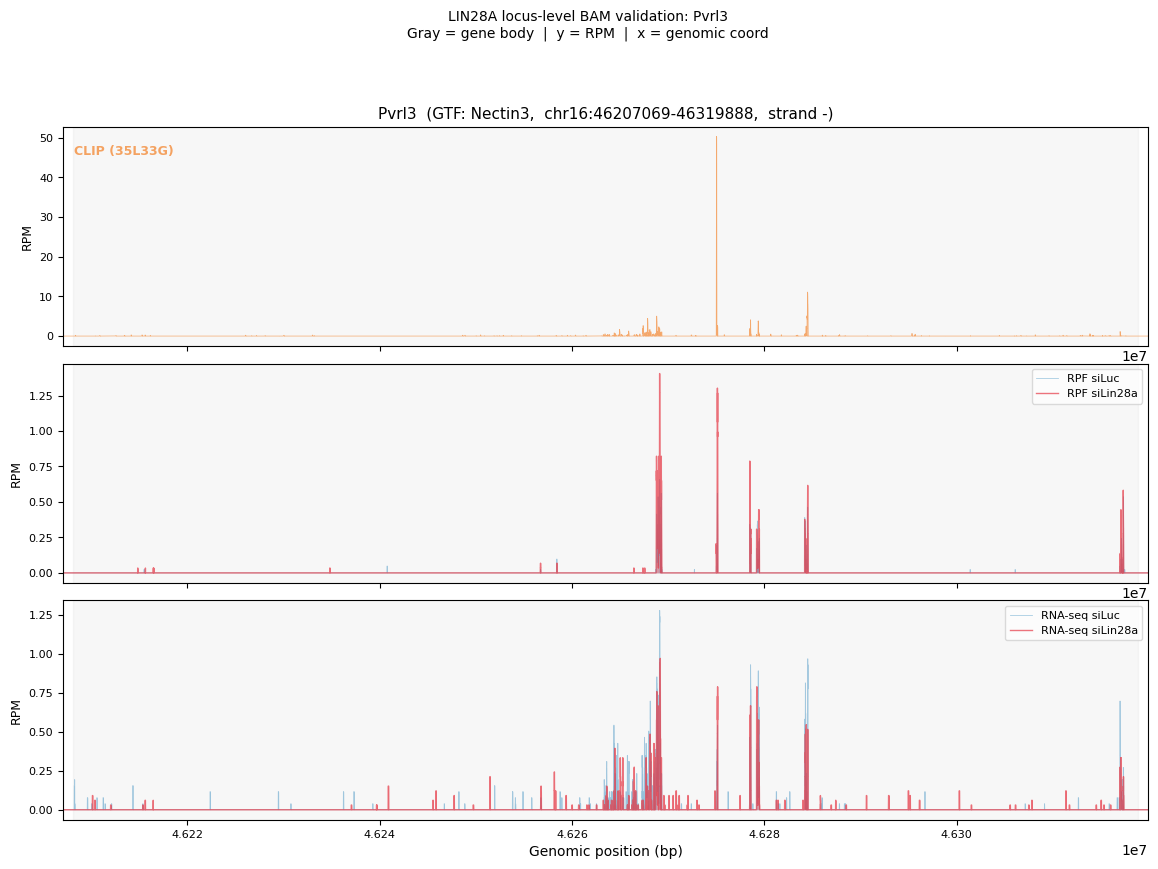

In [7]:
crow = df_coords[df_coords['candidate_gene_symbol'] == 'Pvrl3'].iloc[0]
gene_sym   = 'Pvrl3'
region_str = crow['region_str']
gene_s  = int(crow['start_1b'])
gene_e  = int(crow['end_1b'])
region_s = int(crow['region_start_1b'])
region_e = int(crow['region_end_1b'])
strand   = crow['strand']
gtf_name = crow['gtf_gene_name']

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.08, height_ratios=[1,1,1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Track 1: CLIP
pos, rpm = load_cov(gene_sym, 'CLIP_35L33G')
if pos is not None:
    ax1.fill_between(pos, rpm, alpha=0.7, color=COLORS['CLIP_35L33G'], linewidth=0)
    ax1.plot(pos, rpm, color=COLORS['CLIP_35L33G'], linewidth=0.5, alpha=0.9)
ax1.set_ylabel('RPM', fontsize=9)
ax1.set_title(f"Pvrl3  (GTF: {gtf_name},  {region_str},  strand {strand})", fontsize=11)
ax1.text(0.01, 0.92, 'CLIP (35L33G)', transform=ax1.transAxes,
         fontsize=9, va='top', color=COLORS['CLIP_35L33G'], fontweight='bold')

# Track 2: RPF
for samp, alpha, lw in [('RPF_siLuc',0.45,0.6),('RPF_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax2.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax2.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax2.set_ylabel('RPM', fontsize=9)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.7)

# Track 3: RNA
for samp, alpha, lw in [('RNA_siLuc',0.45,0.6),('RNA_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax3.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax3.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax3.set_ylabel('RPM', fontsize=9)
ax3.set_xlabel('Genomic position (bp)', fontsize=10)
ax3.legend(loc='upper right', fontsize=8, framealpha=0.7)

for ax in [ax1, ax2, ax3]:
    ax.axvspan(gene_s, gene_e, alpha=0.06, color='gray', zorder=0)
    ax.set_xlim(region_s, region_e)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.setp(ax.get_xticklabels(), fontsize=8)
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
fig.suptitle('LIN28A locus-level BAM validation: Pvrl3\n'
             'Gray = gene body  |  y = RPM  |  x = genomic coord',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

### Unc45a

/tmp/claude-1002/ipykernel_341107/295254064.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


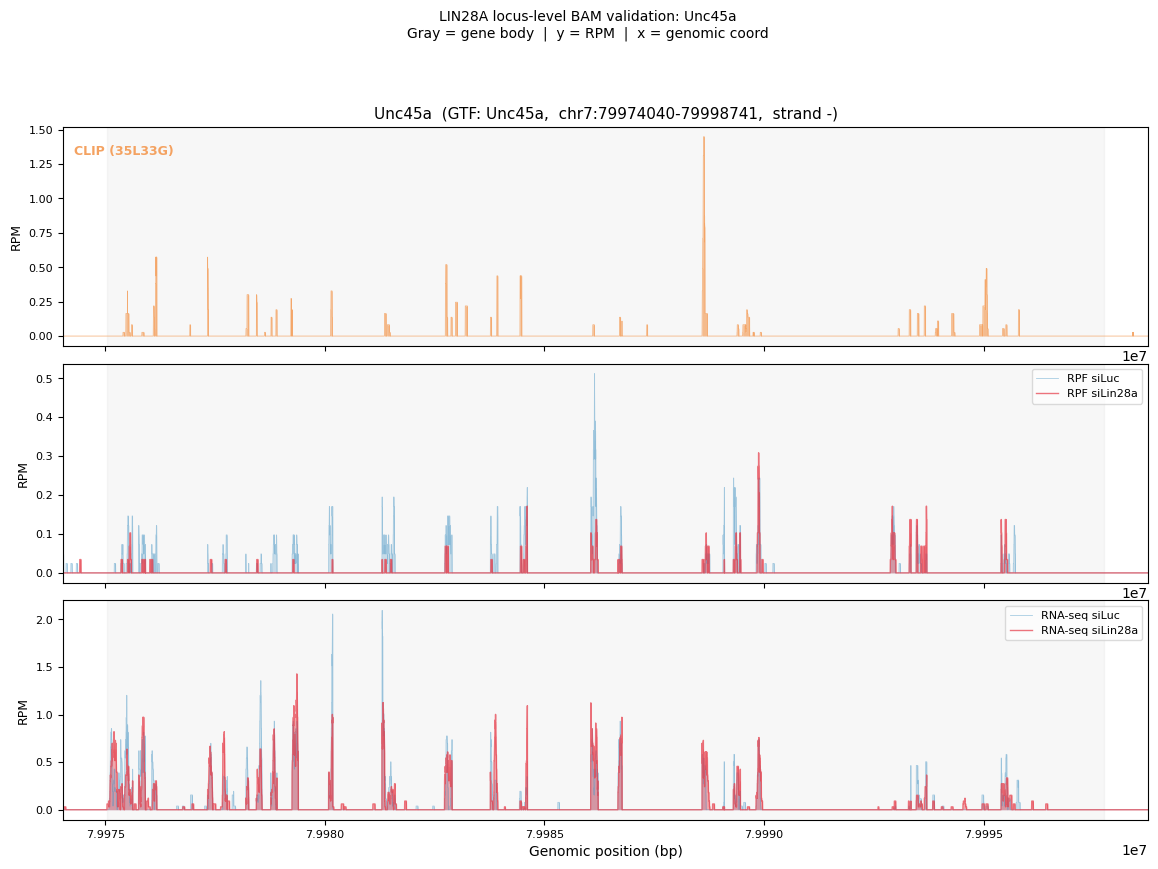

In [8]:
crow = df_coords[df_coords['candidate_gene_symbol'] == 'Unc45a'].iloc[0]
gene_sym   = 'Unc45a'
region_str = crow['region_str']
gene_s  = int(crow['start_1b'])
gene_e  = int(crow['end_1b'])
region_s = int(crow['region_start_1b'])
region_e = int(crow['region_end_1b'])
strand   = crow['strand']
gtf_name = crow['gtf_gene_name']

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.08, height_ratios=[1,1,1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Track 1: CLIP
pos, rpm = load_cov(gene_sym, 'CLIP_35L33G')
if pos is not None:
    ax1.fill_between(pos, rpm, alpha=0.7, color=COLORS['CLIP_35L33G'], linewidth=0)
    ax1.plot(pos, rpm, color=COLORS['CLIP_35L33G'], linewidth=0.5, alpha=0.9)
ax1.set_ylabel('RPM', fontsize=9)
ax1.set_title(f"Unc45a  (GTF: {gtf_name},  {region_str},  strand {strand})", fontsize=11)
ax1.text(0.01, 0.92, 'CLIP (35L33G)', transform=ax1.transAxes,
         fontsize=9, va='top', color=COLORS['CLIP_35L33G'], fontweight='bold')

# Track 2: RPF
for samp, alpha, lw in [('RPF_siLuc',0.45,0.6),('RPF_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax2.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax2.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax2.set_ylabel('RPM', fontsize=9)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.7)

# Track 3: RNA
for samp, alpha, lw in [('RNA_siLuc',0.45,0.6),('RNA_siLin28a',0.7,1.0)]:
    pos, rpm = load_cov(gene_sym, samp)
    if pos is not None:
        ax3.fill_between(pos, rpm, alpha=alpha*0.6, color=COLORS[samp], linewidth=0)
        ax3.plot(pos, rpm, color=COLORS[samp], linewidth=lw, alpha=alpha,
                 label=BAM_LABELS[samp])
ax3.set_ylabel('RPM', fontsize=9)
ax3.set_xlabel('Genomic position (bp)', fontsize=10)
ax3.legend(loc='upper right', fontsize=8, framealpha=0.7)

for ax in [ax1, ax2, ax3]:
    ax.axvspan(gene_s, gene_e, alpha=0.06, color='gray', zorder=0)
    ax.set_xlim(region_s, region_e)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.setp(ax.get_xticklabels(), fontsize=8)
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
fig.suptitle('LIN28A locus-level BAM validation: Unc45a\n'
             'Gray = gene body  |  y = RPM  |  x = genomic coord',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

## 4. Region-level coverage summary

0-filled coverage (includes intron positions). For visualization aid only — not a differential analysis.

In [9]:
df_cov_sum = pd.read_csv(f'{OUT_T}/06_gene_region_coverage_summary.csv')
pd.set_option('display.max_colwidth', 60)
df_cov_sum[['gene_symbol','sample','label','n_positions',
            'mean_raw_depth','max_raw_depth',
            'mean_rpm_depth','max_rpm_depth','pct_covered']]

,gene_symbol,sample,label,n_positions,mean_raw_depth,max_raw_depth,mean_rpm_depth,max_rpm_depth,pct_covered
0,Pgrmc1,CLIP_35L33G,CLIP (35L33G),9874,62.795220,13457.0,1.716196,367.780313,18.887989
1,Pgrmc1,RPF_siLuc,RPF siLuc,9874,3.963946,225.0,0.096664,5.486822,7.443792
2,Pgrmc1,RPF_siLin28a,RPF siLin28a,9874,3.766356,187.0,0.129081,6.408867,7.281750
3,Pgrmc1,RNA_siLuc,RNA-seq siLuc,9874,4.477213,95.0,0.173631,3.684202,22.523800
4,Pgrmc1,RNA_siLin28a,RNA-seq siLin28a,9874,4.873709,138.0,0.147963,4.189601,24.427790
5,Ktn1,CLIP_35L33G,CLIP (35L33G),93447,4.790791,2536.0,0.130932,69.308975,7.238328
6,Ktn1,RPF_siLuc,RPF siLuc,93447,0.324483,86.0,0.007913,2.097185,4.809143
7,Ktn1,RPF_siLin28a,RPF siLin28a,93447,0.279570,71.0,0.009581,2.433313,4.590838
8,Ktn1,RNA_siLuc,RNA-seq siLuc,93447,1.164885,77.0,0.045175,2.986143,12.005736
9,Ktn1,RNA_siLin28a,RNA-seq siLin28a,93447,1.143686,90.0,0.034722,2.732348,15.045962


## 5. BAM vs Table S5 interpretation

**CLIP signal**: `yes` = max_rpm > 5.0; `weak` = max_rpm > 1.0 AND mean_rpm > 0.02; `no` = below.

**RPF pattern**: ratio of mean RPM siLin28a / siLuc. `higher_siLin28a` (>1.3) = derepression after Lin28a KD.

**RNA pattern**: same ratio for RNA-seq. `stable` = 0.77–1.3.

In [10]:
df_interp = pd.read_csv(f'{OUT_T}/06_bam_validation_interpretation_table.csv')
pd.set_option('display.max_colwidth', 70)
df_interp[['Gene Symbol','candidate_type','TableS5_mean_CLIP_enrichment',
           'TableS5_ribosome_density_change','TableS5_mRNA_change',
           'binding_site_count','CLIP_max_rpm_locus','CLIP_mean_rpm_locus',
           'visible_CLIP_signal','RPF_pattern','RNA_pattern',
           'BAM_validation_summary']]

,Gene Symbol,candidate_type,TableS5_mean_CLIP_enrichment,TableS5_ribosome_density_change,TableS5_mRNA_change,binding_site_count,CLIP_max_rpm_locus,CLIP_mean_rpm_locus,visible_CLIP_signal,RPF_pattern,RNA_pattern,BAM_validation_summary
0,Pgrmc1,A_and_B_overlap,4.031423,0.314690,-0.219797,21,367.780313,1.716196,yes,higher_siLin28a (consistent with derepression),stable,consistent with direct translational repression target
1,Ktn1,A_and_B_overlap,2.913330,0.605197,-0.399328,62,69.308975,0.130932,yes,similar,changed,partially consistent — see caveats
2,Pvrl3,A_and_B_overlap,2.882220,0.867100,-0.323691,17,50.259939,0.047290,yes,higher_siLin28a (consistent with derepression),changed,partially consistent — see caveats
3,Unc45a,Not_candidate,-1.860770,-1.964603,0.016138,0,1.448492,0.014673,no,lower_siLin28a,stable,negative control: no CLIP signal; RPF lower after Lin28a KD (expec...


## 6. Key findings

| Gene | CLIP | RPF pattern | RNA | Summary |
|---|---|---|---|---|
| **Pgrmc1** | yes (max 367.8 RPM) | higher siLin28a | stable | Consistent with direct translational repression target |
| **Ktn1** | yes (max 69.3 RPM) | similar | changed | Partially consistent — RPF trend not clear at locus level |
| **Pvrl3** | yes (max 50.3 RPM) | higher siLin28a | changed | RPF pattern consistent; RNA also changed (possible off-target or indirect effect) |
| **Unc45a** | no (max 1.4 RPM) | lower siLin28a | stable | Expected negative control pattern |

**Interpretation**:
- Pgrmc1 shows the clearest pattern consistent with LIN28A-mediated translational repression: strong CLIP signal, RPF increased after Lin28a KD, stable RNA.
- Pvrl3 shows visible CLIP signal and elevated RPF in siLin28a, but RNA also changes, suggesting complex regulation.
- Ktn1 has visible CLIP signal but RPF change is not clear at the locus level (large intronic regions may dilute exonic signal in the gene-body summary).
- Unc45a shows no meaningful CLIP signal and lower RPF in siLin28a, consistent with it being a non-LIN28A target.

> **Caveat**: all interpretation is qualitative / locus-level. No biological replicates. Gene body regions include introns.